# RTU Energy Optimization Using BMS Trend Data

**Project Goal:**  
This project builds a data-driven workflow for evaluating rooftop unit (RTU) efficiency using Building Management System (BMS) trend data. The workflow combines HVAC telemetry, feature engineering, baseline modeling, time-series forecasting, and deep learning to identify inefficient RTU operation.

**Main Idea:**  
The model predicts what RTU operation *should* look like under normal conditions. Actual operation is then compared against the predicted baseline to flag inefficient behavior.

# PowerPoint-Ready Project Walkthrough

## Slide 1 — Project Title
**RTU Energy Optimization Using BMS Trend Data**

This project uses historical HVAC trend data to evaluate RTU performance and identify inefficient operation patterns.

## Slide 2 — Business Problem
Commercial RTUs often run inefficiently because of poor schedules, static setpoints, poor economizer operation, excessive runtime, and limited visibility into real-time performance.

## Slide 3 — Project Objective
The objective is to build an analytics pipeline that predicts expected RTU performance and compares it to actual operation. Deviations from expected performance are used to flag possible inefficiencies.

## Slide 4 — Data Sources
The project uses exported BMS trend data from multiple CSV files, including room temperature, outside air temperature, discharge/supply air temperature, setpoints, and other RTU-related points.

## Slide 5 — Data Preparation
Multiple CSV files are combined into one dataset. Each file is labeled by interval type, such as 10-minute, 15-minute, 30-minute, or baseline data.

## Slide 6 — Feature Engineering
New HVAC features are created, including hour of day, day of week, occupied status, temperature differential, outside-air-to-zone difference, and cooling load proxy.

## Slide 7 — Modeling Approach
The project uses a staged modeling approach:
1. Rule-based HVAC checks
2. Linear regression baseline model
3. SARIMAX time-series forecasting
4. PyTorch LSTM deep learning model

## Slide 8 — Expected vs Actual Performance
The models estimate expected RTU behavior. Actual operation is compared against expected operation to identify abnormal energy or cooling patterns.

## Slide 9 — Inefficiency Detection
Inefficiency is flagged when actual cooling load or energy proxy is significantly higher than the predicted baseline.

## Slide 10 — HVAC Interpretation
Potential issues include poor scheduling, unnecessary fan operation, ineffective cooling, economizer problems, short cycling, and excessive runtime.

## Slide 11 — Project Value
This workflow gives building operators a repeatable method for turning raw BMS trend data into actionable RTU optimization insights.

## Slide 12 — Final Conclusion
The project demonstrates how machine learning and time-series modeling can support HVAC energy optimization by identifying when RTU behavior deviates from expected performance.

# Notebook Roadmap

This notebook follows the full project workflow:

1. Import libraries  
2. Load and combine CSV files  
3. Clean and standardize columns  
4. Explore the dataset  
5. Create HVAC-specific features  
6. Create a cooling load / energy proxy  
7. Run rule-based efficiency checks  
8. Build a linear regression baseline model  
9. Build a SARIMAX time-series model  
10. Build a PyTorch LSTM model  
11. Compare model performance  
12. Create final visualizations  
13. Summarize operational recommendations

## 1. Import Libraries

In [22]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics and modeling
from scipy import stats
from scipy.stats import shapiro

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time-series modeling
from statsmodels.tsa.statespace.sarimax import SARIMAX

# PyTorch deep learning
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load and Combine CSV Files

In [2]:
# Update these file names if your CSV names are different.
files = {
    "10min": "B90_102_exp10m_202104.csv",
    "15min": "B90_102_exp15m_202104.csv",
    "30min": "B90_102_exp30m_202104.csv",
    "nominal": "B90_102_nominal_202104.csv"
}

dfs = []

for label, file in files.items():
    df = pd.read_csv(file)
    df["source"] = label

    if label == "10min":
        df["interval_min"] = 10
    elif label == "15min":
        df["interval_min"] = 15
    elif label == "30min":
        df["interval_min"] = 30
    else:
        df["interval_min"] = 0

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

combined_df.head()

,time,thermostat_room_temp,room_temp,thermostat_outside_temp,supply_discharge_temp,ahu_supply_temp,setpoint,setpoint_max,setpoint_min,clg_sp_current,htg_sp_current,clg_sp_offset,htg_sp_offset,occupied_clg_sp,occupied_htg_sp,unoccupied_clg_sp,unoccupied_htg_sp,htg_valve_position,htg_valve_command,airflow_desired,airflow_current,airflow_max,airflow_min,damper_position,damper_command,htg_signal,clg_signal,htg_clg_mode,occupied_status,source,interval_min
0,2021-04-24T07:45:00.0,70.5,70.5,47,59.0,56.3,69.0,85,65,71.0,68.0,3,0,71.0,68.0,85,55,4.105263,1.130058,406.780334,451,1000,400,83.684212,83.17408,1.130058,0.0,True,True,10min,10
1,2021-04-24T07:46:00.0,70.0,70.3,47,59.0,56.1,69.0,85,65,71.0,68.0,3,0,71.0,68.0,85,55,2.947368,4.871758,429.230530,429,1000,400,83.052635,82.94136,4.838425,0.0,True,True,10min,10
2,2021-04-24T07:47:00.0,70.0,70.3,47,58.6,56.1,69.0,85,65,71.0,68.0,3,0,71.0,68.0,85,55,0.631579,2.855125,417.130737,429,1000,400,83.052635,82.94136,2.821793,0.0,True,True,10min,10
3,2021-04-24T07:48:00.0,70.0,70.2,47,58.7,55.9,69.0,85,65,71.0,68.0,3,0,71.0,68.0,85,55,0.631579,0.855156,405.130920,429,1000,400,83.052635,82.94136,0.821823,0.0,True,True,10min,10
4,2021-04-24T07:49:00.0,70.0,70.1,48,58.5,55.4,69.0,85,65,71.0,68.0,3,0,71.0,68.0,85,55,0.000000,0.000000,400.000000,435,1000,400,83.052635,82.94136,0.000000,0.0,False,True,10min,10


## 3. Clean and Standardize the Dataset

In [4]:
# Convert time to datetime
combined_df["time"] = pd.to_datetime(combined_df["time"], errors="coerce")

# Drop rows where time could not be parsed
combined_df = combined_df.dropna(subset=["time"])

# Sort by time
combined_df = combined_df.sort_values("time")

# Rename common HVAC columns for clarity.
# Only columns that exist will be renamed.
rename_map = {
    "thermostat_outside_temp": "OAT",
    "thermostat_room_temp": "zone_temp",
    "room_temp": "room_temp",
    "supply_discharge_temp": "DAT",
    "ahu_supply_temp": "SAT",
    "setpoint": "zone_setpoint",
    "setpoint_max": "setpoint_max",
    "setpoint_min": "setpoint_min"
}

combined_df = combined_df.rename(columns={k: v for k, v in rename_map.items() if k in combined_df.columns})

# Set time as index
combined_df = combined_df.set_index("time")

# Remove duplicate timestamps if needed by keeping the first occurrence
combined_df = combined_df[~combined_df.index.duplicated(keep="first")]

combined_df.head()

KeyError: 'time'

## 4. Initial Data Review

In [5]:
print("Dataset shape:", combined_df.shape)
print("\nColumns:")
print(combined_df.columns.tolist())

print("\nMissing values:")
display(combined_df.isna().sum().sort_values(ascending=False).head(20))

display(combined_df.describe())

Dataset shape: (12726, 30)

Columns:
['zone_temp', 'room_temp', 'OAT', 'DAT', 'SAT', 'zone_setpoint', 'setpoint_max', 'setpoint_min', 'clg_sp_current', 'htg_sp_current', 'clg_sp_offset', 'htg_sp_offset', 'occupied_clg_sp', 'occupied_htg_sp', 'unoccupied_clg_sp', 'unoccupied_htg_sp', 'htg_valve_position', 'htg_valve_command', 'airflow_desired', 'airflow_current', 'airflow_max', 'airflow_min', 'damper_position', 'damper_command', 'htg_signal', 'clg_signal', 'htg_clg_mode', 'occupied_status', 'source', 'interval_min']

Missing values:


zone_temp             0
room_temp             0
OAT                   0
DAT                   0
SAT                   0
zone_setpoint         0
setpoint_max          0
setpoint_min          0
clg_sp_current        0
htg_sp_current        0
clg_sp_offset         0
htg_sp_offset         0
occupied_clg_sp       0
occupied_htg_sp       0
unoccupied_clg_sp     0
unoccupied_htg_sp     0
htg_valve_position    0
htg_valve_command     0
airflow_desired       0
airflow_current       0
dtype: int64

,zone_temp,room_temp,OAT,DAT,SAT,zone_setpoint,setpoint_max,setpoint_min,clg_sp_current,htg_sp_current,clg_sp_offset,htg_sp_offset,occupied_clg_sp,occupied_htg_sp,unoccupied_clg_sp,unoccupied_htg_sp,htg_valve_position,htg_valve_command,airflow_desired,airflow_current,airflow_max,airflow_min,damper_position,damper_command,htg_signal,clg_signal,interval_min
count,12726.000000,12726.000000,12726.000000,12726.000000,12726.000000,12726.000000,12726.0,12726.0,12726.000000,12726.000000,12726.0,12726.0,12726.000000,12726.000000,12726.0,12726.0,12726.000000,12726.000000,12726.000000,12726.000000,12726.0,12726.0,12726.000000,12726.000000,12726.000000,12726.000000,12726.000000
mean,71.440869,71.646283,50.418670,77.031086,54.947981,72.361740,85.0,65.0,74.360443,71.360522,3.0,0.0,74.361740,71.361740,85.0,55.0,40.179128,40.151722,640.864759,641.895018,1000.0,400.0,80.790921,80.797085,40.158334,0.066737,16.428571
std,1.457944,1.456916,9.153755,10.526781,0.602169,1.755552,0.0,0.0,1.755533,1.754543,0.0,0.0,1.755552,1.755552,0.0,0.0,26.595512,26.502850,158.964870,153.605288,0.0,0.0,7.239931,7.285022,26.493550,0.843060,13.169825
min,68.500000,68.500000,35.000000,56.200000,50.400000,69.000000,85.0,65.0,71.000000,68.000000,3.0,0.0,71.000000,68.000000,85.0,55.0,0.000000,0.000000,400.000000,394.000000,1000.0,400.0,67.157898,66.831718,0.000000,0.000000,0.000000
25%,70.500000,70.900000,43.000000,75.600000,54.700000,71.500000,85.0,65.0,73.500000,70.500000,3.0,0.0,73.500000,70.500000,85.0,55.0,19.157894,19.138887,514.714676,517.000000,1000.0,400.0,74.105263,74.040558,19.090761,0.000000,0.000000
50%,71.000000,71.300000,50.000000,78.600000,55.000000,72.000000,85.0,65.0,74.000000,71.000000,3.0,0.0,74.000000,71.000000,85.0,55.0,45.473682,46.138275,676.829651,669.000000,1000.0,400.0,82.473682,82.565971,46.138275,0.000000,15.000000
75%,72.500000,72.600000,56.000000,83.900000,55.200000,73.500000,85.0,65.0,75.500000,72.500000,3.0,0.0,75.500000,72.500000,85.0,55.0,51.578949,50.246574,701.082855,716.000000,1000.0,400.0,86.210526,86.299263,50.227821,0.000000,30.000000
max,75.500000,75.700000,75.000000,97.000000,63.000000,77.000000,85.0,65.0,79.000000,76.000000,3.0,0.0,79.000000,76.000000,85.0,55.0,100.000000,100.000000,1000.000000,1098.000000,1000.0,400.0,100.000000,99.926720,100.000000,18.024998,30.000000


In [ ]:
4a. Plot

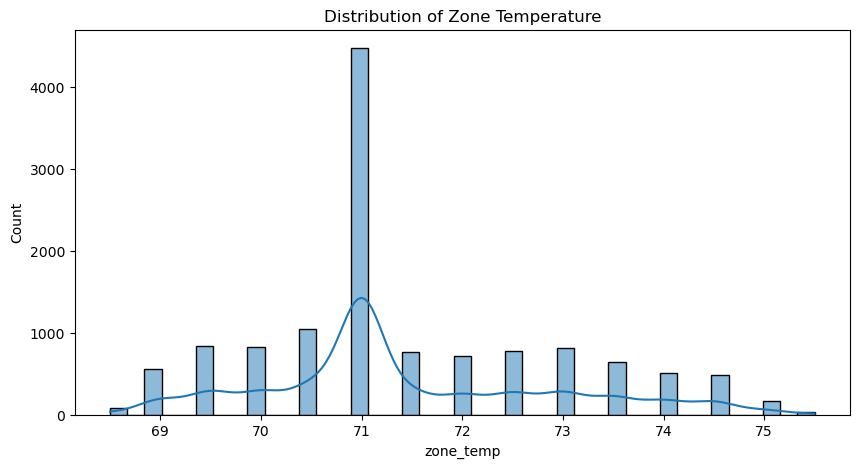

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(combined_df["zone_temp"], kde=True)
plt.title("Distribution of Zone Temperature")
plt.show()

## 5. Create HVAC Features

In [6]:
# Time-based features
combined_df["hour"] = combined_df.index.hour
combined_df["day_of_week"] = combined_df.index.dayofweek
combined_df["month"] = combined_df.index.month

# Occupancy proxy.
# Adjust these hours to match the actual building schedule if known.
combined_df["occupied"] = combined_df["hour"].between(8, 18).astype(int)

# Temperature-based features
if {"zone_temp", "DAT"}.issubset(combined_df.columns):
    combined_df["zone_DAT_delta"] = combined_df["zone_temp"] - combined_df["DAT"]

if {"OAT", "zone_temp"}.issubset(combined_df.columns):
    combined_df["oat_zone_delta"] = combined_df["OAT"] - combined_df["zone_temp"]

if {"zone_temp", "zone_setpoint"}.issubset(combined_df.columns):
    combined_df["zone_setpoint_error"] = combined_df["zone_temp"] - combined_df["zone_setpoint"]

combined_df.head()

,zone_temp,room_temp,OAT,DAT,SAT,zone_setpoint,setpoint_max,setpoint_min,clg_sp_current,htg_sp_current,clg_sp_offset,htg_sp_offset,occupied_clg_sp,occupied_htg_sp,unoccupied_clg_sp,unoccupied_htg_sp,htg_valve_position,htg_valve_command,airflow_desired,airflow_current,airflow_max,airflow_min,damper_position,damper_command,htg_signal,clg_signal,htg_clg_mode,occupied_status,source,interval_min,hour,day_of_week,month,occupied,zone_DAT_delta,oat_zone_delta,zone_setpoint_error
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-04-16 23:45:00,70.0,70.3,48,81.1,55.1,72.0,85,65,74.0,71.0,3,0,74.0,71.0,85,55,56.421051,56.154976,736.929871,738,1000,400,87.473686,87.588631,56.154976,0.0,True,True,nominal,0,23,4,4,0,-11.1,-22.0,-2.0
2021-04-16 23:46:00,70.5,70.5,47,80.3,55.0,72.0,85,65,74.0,71.0,3,0,74.0,71.0,85,55,55.578949,50.996628,705.979736,741,1000,400,87.473686,87.573250,51.004959,0.0,True,True,nominal,0,23,4,4,0,-9.8,-23.5,-1.5
2021-04-16 23:47:00,70.5,70.6,47,80.7,54.4,72.0,85,65,74.0,71.0,3,0,74.0,71.0,85,55,55.578949,51.496620,708.979736,738,1000,400,87.473686,87.573250,51.504951,0.0,True,True,nominal,0,23,4,4,0,-10.2,-23.5,-1.5
2021-04-16 23:48:00,70.5,70.7,47,82.8,54.3,72.0,85,65,74.0,71.0,3,0,74.0,71.0,85,55,55.578949,51.996613,711.979675,741,1000,400,87.473686,87.573250,52.004944,0.0,True,True,nominal,0,23,4,4,0,-12.3,-23.5,-1.5
2021-04-16 23:49:00,70.5,70.8,48,84.9,54.7,72.0,85,65,74.0,71.0,3,0,74.0,71.0,85,55,55.578949,52.496605,714.979614,741,1000,400,87.473686,87.573250,52.504936,0.0,True,True,nominal,0,23,4,4,0,-14.4,-22.5,-1.5


## 6. Create Cooling Load / Energy Proxy

In [7]:
# In many BMS exports, true RTU kW is unavailable.
# This proxy estimates cooling effort based on temperature differential.
# If you have a real kW column, replace cooling_load_proxy with actual kW.

if "fan_status" not in combined_df.columns:
    # Basic fallback: assume fan is active when SAT/DAT data exists.
    if "SAT" in combined_df.columns:
        combined_df["fan_status"] = combined_df["SAT"].notna().astype(int)
    else:
        combined_df["fan_status"] = 1

if {"zone_temp", "DAT", "fan_status"}.issubset(combined_df.columns):
    combined_df["cooling_load_proxy"] = (
        combined_df["fan_status"] *
        (combined_df["zone_temp"] - combined_df["DAT"]).clip(lower=0)
    )
else:
    raise ValueError("Missing required columns to create cooling_load_proxy. Need zone_temp, DAT, and fan_status.")

combined_df[["zone_temp", "DAT", "fan_status", "cooling_load_proxy"]].head()

,zone_temp,DAT,fan_status,cooling_load_proxy
time,,,,
2021-04-16 23:45:00,70.0,81.1,1,0.0
2021-04-16 23:46:00,70.5,80.3,1,0.0
2021-04-16 23:47:00,70.5,80.7,1,0.0
2021-04-16 23:48:00,70.5,82.8,1,0.0
2021-04-16 23:49:00,70.5,84.9,1,0.0


## 7. Rule-Based RTU Efficiency Checks

In [8]:
# Rule 1: Fan active during unoccupied periods
combined_df["flag_unoccupied_fan"] = (
    (combined_df["occupied"] == 0) &
    (combined_df["fan_status"] == 1)
)

# Rule 2: High cooling load during unoccupied periods
threshold_load = combined_df["cooling_load_proxy"].quantile(0.75)
combined_df["flag_unoccupied_high_load"] = (
    (combined_df["occupied"] == 0) &
    (combined_df["cooling_load_proxy"] > threshold_load)
)

# Rule 3: Zone temperature above setpoint during occupied hours
if "zone_setpoint_error" in combined_df.columns:
    combined_df["flag_comfort_issue"] = (
        (combined_df["occupied"] == 1) &
        (combined_df["zone_setpoint_error"] > 2)
    )
else:
    combined_df["flag_comfort_issue"] = False

# Summary
rule_summary = combined_df[
    ["flag_unoccupied_fan", "flag_unoccupied_high_load", "flag_comfort_issue"]
].sum()

display(rule_summary)

flag_unoccupied_fan          6750
flag_unoccupied_high_load    1352
flag_comfort_issue             31
dtype: int64

## 8. Baseline Linear Regression Model

In [9]:
# Select modeling features that exist in the dataset
candidate_features = [
    "OAT",
    "zone_temp",
    "DAT",
    "SAT",
    "hour",
    "day_of_week",
    "occupied",
    "zone_DAT_delta",
    "oat_zone_delta",
    "zone_setpoint_error"
]

features = [col for col in candidate_features if col in combined_df.columns]
target = "cooling_load_proxy"

model_df = combined_df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

# Time-aware split: first 80% train, last 20% test
split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MAE:", round(mae_lr, 4))
print("RMSE:", round(rmse_lr, 4))
print("R2:", round(r2_lr, 4))

Linear Regression Performance
MAE: 2.0903
RMSE: 2.4894
R2: 0.7859


## 9. Linear Regression Visualization

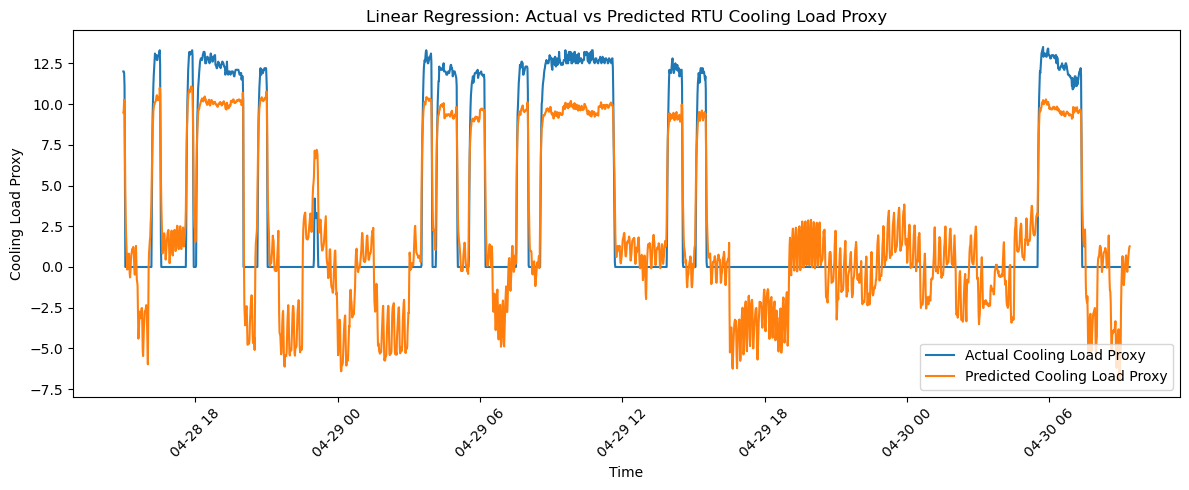

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Actual Cooling Load Proxy")
plt.plot(y_test.index, y_pred_lr, label="Predicted Cooling Load Proxy")
plt.title("Linear Regression: Actual vs Predicted RTU Cooling Load Proxy")
plt.xlabel("Time")
plt.ylabel("Cooling Load Proxy")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Regression-Based Inefficiency Flag

In [11]:
# Store predictions back into the main dataframe for the test period
combined_df.loc[y_test.index, "lr_predicted_load"] = y_pred_lr
combined_df.loc[y_test.index, "lr_error"] = combined_df.loc[y_test.index, "cooling_load_proxy"] - combined_df.loc[y_test.index, "lr_predicted_load"]

# Flag if actual load is significantly higher than predicted
error_threshold = combined_df.loc[y_test.index, "lr_error"].std()
combined_df.loc[y_test.index, "lr_inefficient_flag"] = combined_df.loc[y_test.index, "lr_error"] > error_threshold

combined_df.loc[y_test.index, ["cooling_load_proxy", "lr_predicted_load", "lr_error", "lr_inefficient_flag"]].head()

,cooling_load_proxy,lr_predicted_load,lr_error,lr_inefficient_flag
time,,,,
2021-04-28 14:58:00,12.0,9.477263,2.522737,True
2021-04-28 14:59:00,12.0,9.603270,2.396730,True
2021-04-28 15:00:00,11.9,10.261692,1.638308,False
2021-04-28 15:01:00,11.1,9.979804,1.120196,False
2021-04-28 15:02:00,5.8,7.328691,-1.528691,False


## 11. SARIMAX Time-Series Model

In [12]:
# SARIMAX can be computationally heavy.
# For a classroom project, use a smaller clean sample if the dataset is large.

sarimax_features = [col for col in ["OAT", "zone_temp", "occupied"] if col in combined_df.columns]

sarimax_df = combined_df[[target] + sarimax_features].dropna().copy()

# Optional: resample to 15-minute intervals for consistent spacing
sarimax_df = sarimax_df.resample("15min").mean().dropna()

# Seasonal period:
# 15-minute data = 96 intervals per day.
seasonal_period = 96

# Limit size if needed to prevent long runtime
sarimax_sample = sarimax_df.tail(min(len(sarimax_df), 2000))

y_sarimax = sarimax_sample[target]
exog_sarimax = sarimax_sample[sarimax_features]

sarimax_model = SARIMAX(
    y_sarimax,
    exog=exog_sarimax,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, seasonal_period),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit(disp=False)

print(sarimax_results.summary())

C:\Users\thoja\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thoja\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thoja\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                 cooling_load_proxy   No. Observations:                  850
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 96)   Log Likelihood               -1719.207
Date:                            Sun, 03 May 2026   AIC                           3454.414
Time:                                    17:59:55   BIC                           3490.291
Sample:                                         0   HQIC                          3468.325
                                            - 850                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
OAT           -0.0498      0.046     -1.091      0.275      -0.139       0.040
zone_temp     -1.7378      0.236   

In [13]:
sarimax_df = combined_df[[target] + sarimax_features].dropna().copy()

# Resample to fixed 15-minute intervals
sarimax_df = sarimax_df.resample("15min").mean()

# Fill missing values after resampling
sarimax_df = sarimax_df.interpolate(method="time")

# Force fixed frequency
sarimax_df = sarimax_df.asfreq("15min")

In [14]:
seasonal_period = 96

sarimax_sample = sarimax_df.tail(min(len(sarimax_df), 2000))

y_sarimax = sarimax_sample[target]
exog_sarimax = sarimax_sample[sarimax_features]

sarimax_model = SARIMAX(
    y_sarimax,
    exog=exog_sarimax,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, seasonal_period),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit(disp=False)
## The data was resampled to a fixed 15-minute interval so the SARIMAX model could properly recognize the time-series frequency and daily seasonal pattern.

## 12. SARIMAX Predictions and Visualization

C:\Users\thoja\AppData\Local\Temp\ipykernel_23452\2960277830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sarimax_sample["sarimax_predicted_load"] = sarimax_results.fittedvalues


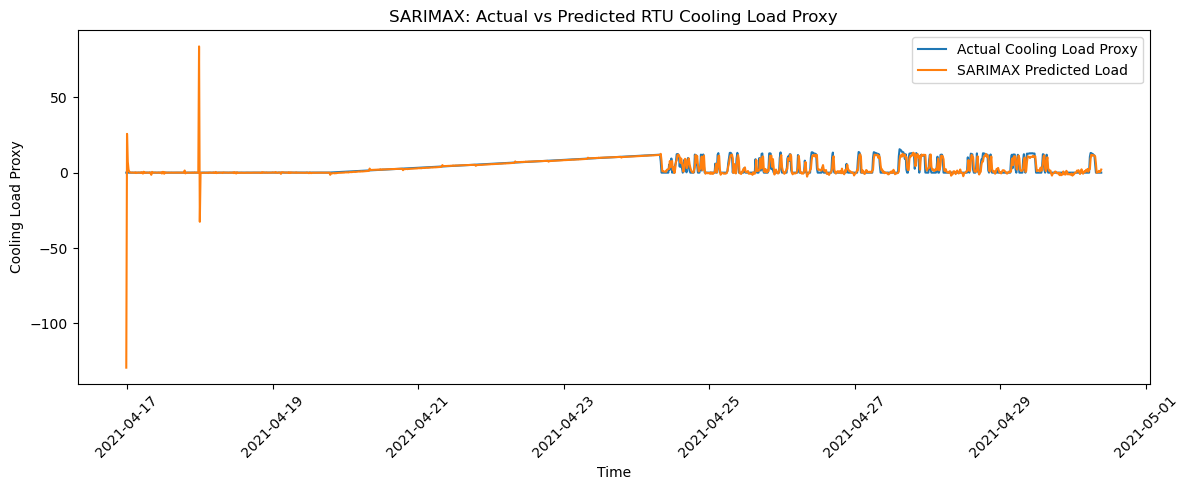

In [15]:
sarimax_sample["sarimax_predicted_load"] = sarimax_results.fittedvalues

plt.figure(figsize=(12, 5))
plt.plot(sarimax_sample.index, sarimax_sample[target], label="Actual Cooling Load Proxy")
plt.plot(sarimax_sample.index, sarimax_sample["sarimax_predicted_load"], label="SARIMAX Predicted Load")
plt.title("SARIMAX: Actual vs Predicted RTU Cooling Load Proxy")
plt.xlabel("Time")
plt.ylabel("Cooling Load Proxy")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. PyTorch LSTM Model Preparation

In [16]:
# Prepare data for PyTorch LSTM
pytorch_features = features.copy()
pytorch_df = combined_df[pytorch_features + [target]].dropna().copy()

# Time-aware split
split_idx = int(len(pytorch_df) * 0.8)

train_df = pytorch_df.iloc[:split_idx]
test_df = pytorch_df.iloc[split_idx:]

# Scale features and target
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(train_df[pytorch_features])
X_test_scaled = feature_scaler.transform(test_df[pytorch_features])

y_train_scaled = target_scaler.fit_transform(train_df[[target]])
y_test_scaled = target_scaler.transform(test_df[[target]])

def create_sequences(X, y, window_size=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

window_size = 24

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, window_size)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, window_size)

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

print("Training tensor shape:", X_train_tensor.shape)
print("Testing tensor shape:", X_test_tensor.shape)

Training tensor shape: torch.Size([10156, 24, 10])
Testing tensor shape: torch.Size([2522, 24, 10])


## 14. Build PyTorch LSTM Model

In [17]:
class RTULSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        last_output = output[:, -1, :]
        prediction = self.fc(last_output)
        return prediction

input_size = X_train_tensor.shape[2]

lstm_model = RTULSTM(input_size=input_size, hidden_size=64)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

lstm_model

RTULSTM(
  (lstm): LSTM(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

## 15. Train PyTorch LSTM

In [18]:
epochs = 50

train_losses = []

for epoch in range(epochs):
    lstm_model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        y_pred = lstm_model(X_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")

Epoch 0, Loss: 0.160256
Epoch 10, Loss: 0.011798
Epoch 20, Loss: 0.004685
Epoch 30, Loss: 0.004637
Epoch 40, Loss: 0.005281


## 16. Evaluate PyTorch LSTM

In [19]:
lstm_model.eval()

with torch.no_grad():
    y_pred_lstm_scaled = lstm_model(X_test_tensor).numpy()

# Convert predictions back to original scale
y_pred_lstm = target_scaler.inverse_transform(y_pred_lstm_scaled)
y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1))

mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))
r2_lstm = r2_score(y_test_actual, y_pred_lstm)

print("PyTorch LSTM Performance")
print("MAE:", round(mae_lstm, 4))
print("RMSE:", round(rmse_lstm, 4))
print("R2:", round(r2_lstm, 4))

PyTorch LSTM Performance
MAE: 0.1845
RMSE: 0.3276
R2: 0.9963


## 17. PyTorch Visualization

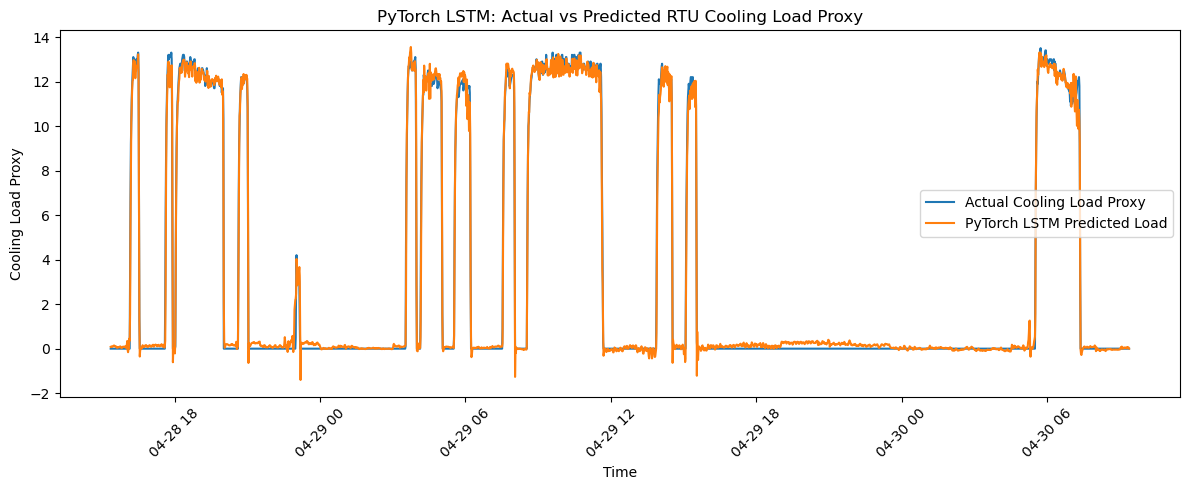

In [20]:
# Align LSTM predictions with test dataframe timestamps
lstm_index = test_df.index[window_size:]

plt.figure(figsize=(12, 5))
plt.plot(lstm_index, y_test_actual.flatten(), label="Actual Cooling Load Proxy")
plt.plot(lstm_index, y_pred_lstm.flatten(), label="PyTorch LSTM Predicted Load")
plt.title("PyTorch LSTM: Actual vs Predicted RTU Cooling Load Proxy")
plt.xlabel("Time")
plt.ylabel("Cooling Load Proxy")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 18. Compare Model Performance

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "PyTorch LSTM"],
    "MAE": [mae_lr, mae_lstm],
    "RMSE": [rmse_lr, rmse_lstm],
    "R2": [r2_lr, r2_lstm]
})

display(model_comparison)

## 19. Final Inefficiency Detection Using Best Model

In [ ]:
# Use LSTM predictions for final inefficiency flag
results_df = pd.DataFrame(index=lstm_index)
results_df["actual_load"] = y_test_actual.flatten()
results_df["predicted_load"] = y_pred_lstm.flatten()
results_df["error"] = results_df["actual_load"] - results_df["predicted_load"]

# Flag abnormal operation when actual load is more than one standard deviation above prediction
threshold = results_df["error"].std()
results_df["inefficient_flag"] = results_df["error"] > threshold

display(results_df.head())

print("Total inefficient intervals flagged:", results_df["inefficient_flag"].sum())

## 20. Final Inefficiency Visualization

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(results_df.index, results_df["actual_load"], label="Actual Load")
plt.plot(results_df.index, results_df["predicted_load"], label="Predicted Load")

flagged = results_df[results_df["inefficient_flag"]]

plt.scatter(
    flagged.index,
    flagged["actual_load"],
    label="Flagged Inefficient Operation"
)

plt.title("RTU Inefficiency Detection Using PyTorch LSTM")
plt.xlabel("Time")
plt.ylabel("Cooling Load Proxy")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 21. Operational Recommendations

In [ ]:
# Basic recommendation logic
recommendations = []

if combined_df["flag_unoccupied_fan"].sum() > 0:
    recommendations.append("Review RTU schedule. Fan appears active during unoccupied periods.")

if combined_df["flag_unoccupied_high_load"].sum() > 0:
    recommendations.append("Review after-hours cooling operation. Cooling load appears elevated during unoccupied periods.")

if combined_df["flag_comfort_issue"].sum() > 0:
    recommendations.append("Review occupied comfort control. Zone temperature appears above setpoint during occupied hours.")

if results_df["inefficient_flag"].sum() > 0:
    recommendations.append("Investigate intervals where actual load exceeds predicted baseline. Possible causes include poor economizer operation, excessive runtime, or control tuning issues.")

print("Recommended RTU Optimization Actions:")
for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

# Final Project Summary

This notebook demonstrated a complete RTU optimization workflow using BMS trend data. The workflow combined multiple CSV trend exports, standardized the data, created HVAC-specific features, built a cooling load proxy, and applied several modeling techniques.

The project used a staged approach:
1. Rule-based HVAC checks  
2. Linear regression baseline modeling  
3. SARIMAX time-series forecasting  
4. PyTorch LSTM deep learning  

The main output is an inefficiency detection workflow that compares actual RTU behavior against predicted expected operation. When actual load exceeds the model baseline, the interval is flagged for review.

This approach can support energy analytics, fault detection, predictive maintenance, and RTU control optimization.